In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

In [2]:
pwd

'C:\\Users\\admin\\OneDrive\\Documents\\deep learing'

In [3]:
# Load dataset
df = pd.read_csv("Boston-house-price-data.csv")

In [4]:
# Split
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
# Early Stopping
early_stop = EarlyStopping(
    patience=10,             #If val_loss does not improve for 10 consecutive epochs,Training will stop automatically
    restore_best_weights=True,
    monitor='val_loss')

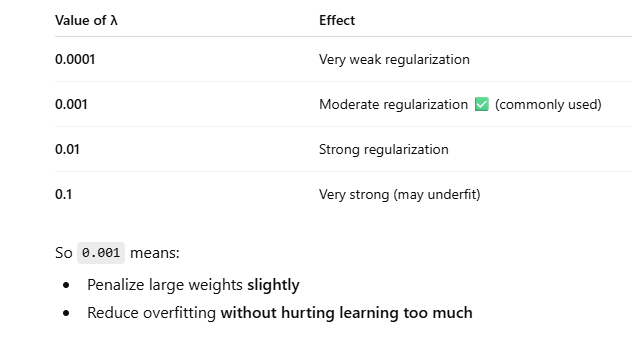

In [8]:

# Model with multiple regularization techniques
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=l2(0.001))) 
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu', kernel_regularizer=l1(0.001))) 
#λ = 0.001 controls how strongly the model punishes large weights.
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer=Adam(0.001), loss='mse', metrics=[tf.keras.metrics.R2Score()])


In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 614.9005 - r2_score: -5.7497 - val_loss: 541.0840 - val_r2_score: -6.7656
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 588.3940 - r2_score: -5.4586 - val_loss: 517.6075 - val_r2_score: -6.4284
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 562.3632 - r2_score: -5.1727 - val_loss: 488.4257 - val_r2_score: -6.0094
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 526.4428 - r2_score: -4.7782 - val_loss: 450.8006 - val_r2_score: -5.4691
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 481.4640 - r2_score: -4.2842 - val_loss: 402.7943 - val_r2_score: -4.7797
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 424.0622 - r2_score: -3.6538 - val_loss: 343.3286 - val_r2_score: -3.9258
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 351.6934 - r2_score: -2.8590 - val_loss: 277.4212 - val_r2_score: -2.9793
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 28

In [10]:
loss, r2 = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test R2 Score:", r2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 15.0302 - r2_score: 0.7996
Test Loss: 15.030165672302246
Test R2 Score: 0.799621045589447


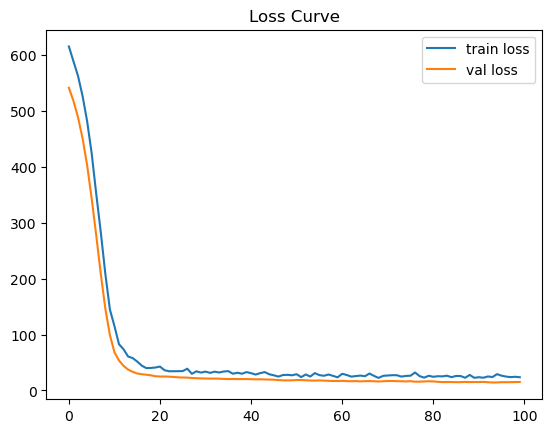

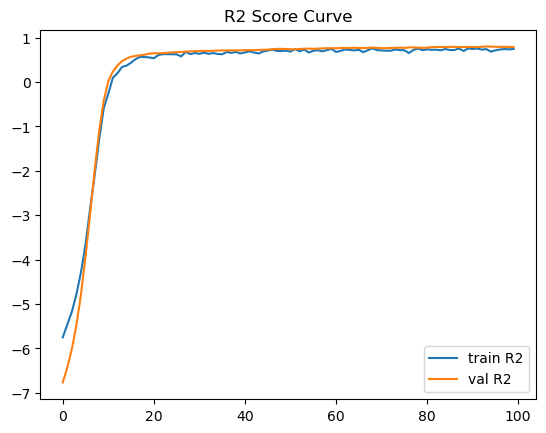

In [11]:
import matplotlib.pyplot as plt

# LOSS
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

# R2 Score
plt.plot(history.history['r2_score'], label='train R2')
plt.plot(history.history['val_r2_score'], label='val R2')
plt.legend()
plt.title("R2 Score Curve")
plt.show()
